# social_text 全年推理结果分析

本 notebook 分析**全年 12 个月**的推理结果（`artifacts/social_text_probs_YYYYMM.csv`）。
推理本身由 `scripts/infer_social_text.py` 完成（双卡 fp16），本册只读产物做分析：
逐月概况 / 概率分布 / 日度-个股聚合 / pooling 对比 / 可视化。

**契约提醒（模型输出未确认项）：**
- 标签 `class_0/1` 语义未确认，**不要**命名为正面/负面/看多/看空；
- pooling 未确认（候选 `cls / pooler / masked_mean`），默认 `cls`，本册末尾有对比；
- 结果为 fp16，与 fp32 概率约有 ~1e-3 差异。

**前置**：全年 12 个结果 CSV 已生成（`artifacts/social_text_probs_202401..202412.csv`）。
若只生成了部分月份，cell 2 会自动跳过缺失月份。

In [1]:
# 环境与导入
%matplotlib inline
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DATA_DIR = os.path.join(ROOT, "filtered_data")
OUT_DIR  = os.path.join(ROOT, "artifacts")
print("python:", sys.version.split()[0], "| numpy:", np.__version__, "| pandas:", pd.__version__)

python: 3.10.18 | numpy: 1.24.4 | pandas: 1.5.3


In [2]:
# 加载全年推理结果(12个月 concat, 排除 --limit 小样本产物)
Months = sorted(f[len("social_text_probs_"):-len(".csv")] for f in os.listdir(OUT_DIR)
                if f.startswith("social_text_probs_") and f.endswith(".csv") and "_lim" not in f)
# 想快速试跑可只取前几个月: Months = Months[:2]
print("将加载月份:", Months)

frames, missing = [], []
for m in Months:
    p = os.path.join(OUT_DIR, f"social_text_probs_{m}.csv")
    if os.path.exists(p):
        df = pd.read_csv(p, dtype={"class_0_prob": np.float32, "class_1_prob": np.float32})
        df["month"] = f"{m[:4]}-{m[4:]}"           # "2024-01"
        frames.append(df)
    else:
        missing.append(m)
if missing:
    print("缺失月份(跳过):", missing)
if not frames:
    raise RuntimeError("没有可用的结果 CSV, 请先运行 scripts/infer_social_text.py")

res = pd.concat(frames, ignore_index=True)
del frames
print("合并完成: shape =", res.shape, "| 月份数 =", len(Months), "| 内存 ~%.1f GB" % (res.memory_usage(deep=True).sum()/1e9))
print("列:", list(res.columns))
res.head(3)

将加载月份: ['202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409', '202410', '202411', '202412']
合并完成: shape = (90627625, 9) | 月份数 = 12 | 内存 ~44.8 GB
列: ['id', 'class_0_prob', 'class_1_prob', 'symbol', 'published_at', 'date', 'available_date', 'source', 'month']


,id,class_0_prob,class_1_prob,symbol,published_at,date,available_date,source,month
0,guba_post_1386917100,0.761719,0.238281,SH600157,2024-01-01T00:00:00+08:00,2024-01-01,2024-01-02,guba_post,2024-01
1,guba_post_1386958256,0.857910,0.142090,SZ002354,2024-01-01T00:00:00+08:00,2024-01-01,2024-01-02,guba_post,2024-01
2,xq_post_273081670,0.777832,0.222412,SH600900,2024-01-01T00:00:01+08:00,2024-01-01,2024-01-02,xq_post,2024-01


In [3]:
# 结果体检: 逐月行数 / NaN / 概率和 / 来源 / 日期对齐
print("逐月行数:")
print(res.groupby("month").size().rename("n_texts").to_string())
print()
print("NaN 数(class_0/1):", int(res[["class_0_prob", "class_1_prob"]].isna().sum().sum()))
s = res["class_0_prob"] + res["class_1_prob"]
print("概率和 max|sum-1|:", round(abs(s - 1).max(), 6))
print()
print("来源分布:")
print(res["source"].value_counts().to_string())
print()
print("各月 available_date 覆盖的交易日数:")
print(res.groupby("month")["available_date"].nunique().rename("n_trading_days").to_string())
print()
print("date -> available_date 抽样:")
print(res[["date", "available_date"]].drop_duplicates().sort_values("date").head(8).to_string())

逐月行数:
month
2024-01     6168821
2024-02     4212502
2024-03     7102968
2024-04     8688867
2024-05     7905609
2024-06     6883760
2024-07     7107722
2024-08     7105227
2024-09     5946247
2024-10     7412554
2024-11    11033655
2024-12    11059693

NaN 数(class_0/1): 0
概率和 max|sum-1|: 0.000244

来源分布:
guba_post    39143457
guba_cmt     38594630
xq_cmt        7323984
xq_post       5565554

各月 available_date 覆盖的交易日数:
month
2024-01    23
2024-02    16
2024-03    22
2024-04    21
2024-05    21
2024-06    20
2024-07    24
2024-08    23
2024-09    20
2024-10    19
2024-11    22
2024-12    23

date -> available_date 抽样:
              date available_date
0       2024-01-01     2024-01-02
41119   2024-01-02     2024-01-02
150608  2024-01-02     2024-01-03
199260  2024-01-03     2024-01-03
370432  2024-01-03     2024-01-04
418150  2024-01-04     2024-01-04
497127  2024-01-04     2024-01-05
698097  2024-01-05     2024-01-08


In [4]:
# class_1_prob 分布: 整体 + 逐月
print("class_1_prob 整体分布:")
print(res["class_1_prob"].describe().round(4).to_string())
print()
mm = res.groupby("month")["class_1_prob"].agg(["mean", "median", "std", "count"])
print("逐月 class_1_prob:")
print(mm.round(4).to_string())

class_1_prob 整体分布:
count    9.062762e+07
mean     1.713000e-01
std      8.740000e-02
min      4.730000e-02
25%      1.410000e-01
50%      1.649000e-01
75%      1.937000e-01
max      6.621000e-01

逐月 class_1_prob:
           mean  median     std     count
month                                    
2024-01  0.1710  0.1648  0.0432   6168821
2024-02  0.1711  0.1652  0.0425   4212502
2024-03  0.1719  0.1655  0.0439   7102968
2024-04  0.1763  0.1678  0.0494   8688867
2024-05  0.1712  0.1653  0.0427   7905609
2024-06  0.1710  0.1653  0.0419   6883760
2024-07  0.1720  0.1658  0.0432   7107722
2024-08  0.1743  0.1666  0.0472   7105227
2024-09  0.1708  0.1648  0.0428   5946247
2024-10  0.1714  0.1652  0.0436   7412554
2024-11  0.1684  0.1628  0.0412  11033655
2024-12  0.1684  0.1627  0.0412  11059693


/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAPH-62BD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27175/3238993625.py:23: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAP

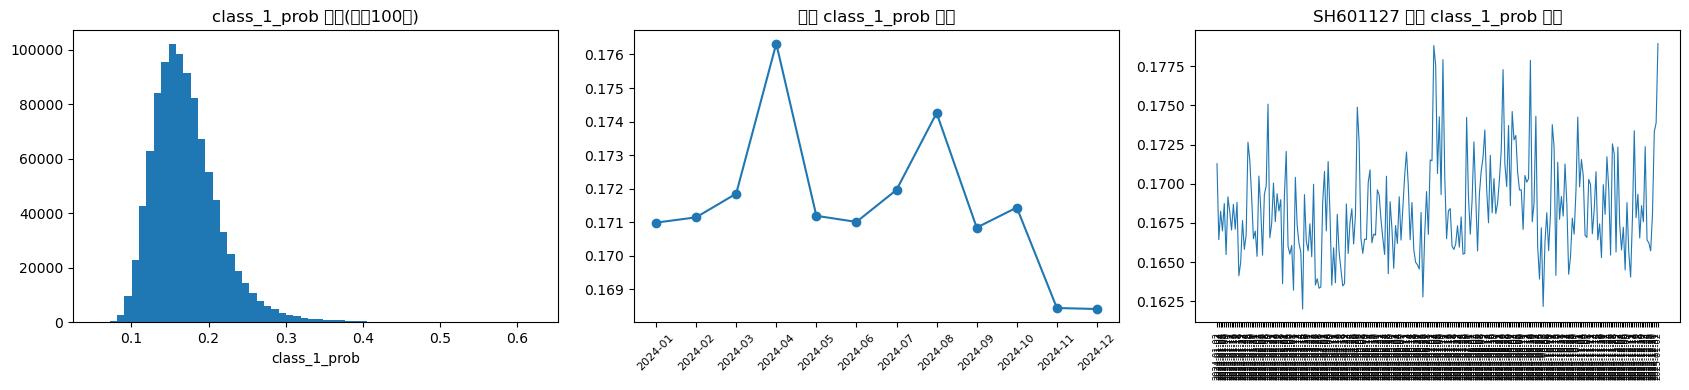

In [5]:
# 可视化: 直方图 / 逐月情绪均值 / 样本个股日度时序
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1) 直方图(抽样100万, 避免90M点过重)
samp = res["class_1_prob"].sample(min(1_000_000, len(res)), random_state=0)
axes[0].hist(samp, bins=60)
axes[0].set_title("class_1_prob 分布(抽样100万)")
axes[0].set_xlabel("class_1_prob")

# 2) 逐月情绪均值
mm = res.groupby("month")["class_1_prob"].mean()
axes[1].plot(mm.index, mm.values, marker="o")
axes[1].set_title("逐月 class_1_prob 均值")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

# 3) 样本个股日度情绪均值时序
top_sym = res["symbol"].value_counts().index[0]
d = (res[res["symbol"] == top_sym]
     .groupby("available_date")["class_1_prob"].mean().sort_index())
axes[2].plot(d.index.astype(str), d.values, lw=0.8)
axes[2].set_title(f"{top_sym} 日度 class_1_prob 均值")
axes[2].tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

In [6]:
# 日度-个股情绪分数(全年聚合) + 落盘
daily = (res.groupby(["available_date", "symbol"])["class_1_prob"]
         .agg(["mean", "median", "std", "count"]).reset_index())
daily.columns = ["available_date", "symbol", "sentiment_mean", "sentiment_median", "sentiment_std", "n_texts"]
daily = daily.sort_values(["available_date", "symbol"])
DAILY_PATH = os.path.join(OUT_DIR, "social_text_daily_2024.csv")
daily.to_csv(DAILY_PATH, index=False)
print(f"全年聚合: {daily.shape[0]} 行 (交易日 x 个股) -> {DAILY_PATH}")
daily.head()

全年聚合: 1305973 行 (交易日 x 个股) -> /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/social_text_daily_2024.csv


,available_date,symbol,sentiment_mean,sentiment_median,sentiment_std,n_texts
0,2024-01-02,BJ400158,0.197683,0.183716,0.060509,19
1,2024-01-02,BJ430017,0.183207,0.168823,0.059902,6
2,2024-01-02,BJ430046,0.203622,0.181274,0.076214,7
3,2024-01-02,BJ430047,0.179281,0.195557,0.035063,3
4,2024-01-02,BJ430090,0.160140,0.152222,0.032574,30


---

## 附加：源文件体检（空文本 / 截断，可选）

对**原始源文件**（`filtered_data`，含 text）做抽样检查，与模型无关。按需运行。

In [7]:
# 空文本 / 截断检查(抽样源文件)
SMONTH = "202403"
src = pd.read_csv(os.path.join(DATA_DIR, f"social_text_{SMONTH}.csv.gz"),
                  usecols=["text"], nrows=2_000_000)
n_empty = int((src["text"].fillna("").str.strip() == "").sum())
print(f"{SMONTH} 抽样 200万: 空文本 {n_empty} ({n_empty/len(src):.2%})")

from transformers import BertTokenizerFast
from src.config import load_yaml_config
cfg = load_yaml_config(os.path.join(ROOT, "configs", "model.yaml"))
base = os.path.join(ROOT, cfg["paths"]["base_model_dir"])
tok = BertTokenizerFast.from_pretrained(base, local_files_only=True)
sub = src["text"].fillna("").head(2000).tolist()
lens = np.array([len(x) for x in tok(sub, add_special_tokens=True)["input_ids"]])
print(f"截断: 抽样 2000 条, >128 token 占比 {(lens > 128).mean():.2%}, 中位长度 {np.median(lens):.0f}")

202403 抽样 200万: 空文本 0 (0.00%)
截断: 抽样 2000 条, >128 token 占比 10.05%, 中位长度 22


---

## pooling 三候选对比（pooling 未确认 → 看输出一致性）

复用脚本的**预缓存**对同一样本分别跑 `cls / pooler / masked_mean` 前向，比较 `class_1_prob` 相关系数。
若缓存不存在会先自动跑一个 `--limit 小样本`（不影响正式结果）。

In [8]:
# pooling 对比（纯前向，走预缓存，不 tokenize）
import subprocess, json
import torch
from src.config import load_yaml_config
from src.models.modeling import build_candidate

PMONTH = "202403"          # 抽样月份
SAMPLE = 3000
cfg = load_yaml_config(os.path.join(ROOT, "configs", "model.yaml"))
base = os.path.join(ROOT, cfg["paths"]["base_model_dir"])
ckpt = os.path.join(ROOT, cfg["paths"]["checkpoint"])

sample_cache = os.path.join(OUT_DIR, "token_cache", f"social_text_{PMONTH}_lim{SAMPLE}_len128_ids.npy")
meta_path = sample_cache + ".meta.json"
if not (os.path.exists(sample_cache) and os.path.exists(meta_path)):
    print(f"生成样本缓存(--limit {SAMPLE})...")
    subprocess.run([sys.executable, os.path.join(ROOT, "scripts", "infer_social_text.py"),
                    "--month", PMONTH, "--gpus", "0", "--limit", str(SAMPLE), "--dtype", "fp16"],
                   cwd=ROOT, check=True)

meta = json.load(open(meta_path, encoding="utf-8"))
pad = int(meta["pad_token_id"])
mm = np.load(sample_cache, mmap_mode="r")
ids = torch.from_numpy(mm[:SAMPLE].astype("int64"))
mask = (ids != pad)
device = "cuda" if torch.cuda.is_available() else "cpu"
ids = ids.to(device); mask = mask.to(device)

comp = {}
for p in ["cls", "pooler", "masked_mean"]:
    m = build_candidate(base, ckpt, pooling=p, pooling_confirmed=False,
                        device=device, dtype=torch.float16).eval()
    with torch.inference_mode():
        probs = m(ids, attention_mask=mask).probabilities.float()[:, 1].cpu()
    comp[p] = probs.numpy()
    del m

cmp = pd.DataFrame(comp)
print(f"三种 pooling 的 class_1_prob（样本 {SAMPLE}）相关系数矩阵:")
print(cmp.corr().round(4).to_string())
print("\n均值:")
print(cmp.mean().round(4).to_string())

生成样本缓存(--limit 3000)...
预 tokenize: 3000 条, max_length=128, workers=32, 125 个分片
预 tokenize 完成: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/token_cache/social_text_202403_lim3000_len128_ids.npy 形状 (3000, 128), 用时 1.6s (1823 条/s)
[part None/1] device=cuda (NVIDIA A100 80GB PCIe) dtype=fp16 pooling=cls batch=1024


/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


  3000/3000  2572条/s  ETA 0.0min
[part None] 完成 3000 行, 前向耗时 1.2s, 吞吐 2572 条/s
已保存: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/social_text_probs_202403_lim3000.csv | 行数: 3000
NaN 校验: 0


/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


三种 pooling 的 class_1_prob（样本 3000）相关系数矩阵:
                cls  pooler  masked_mean
cls          1.0000 -0.1864       0.6292
pooler      -0.1864  1.0000      -0.3228
masked_mean  0.6292 -0.3228       1.0000

均值:
cls            0.1856
pooler         0.5676
masked_mean    0.3973


---

## 结论与下一步

- 全年 12 个月推理结果已在本册完成：**逐月概况 / 概率分布 / 日度-个股聚合(`artifacts/social_text_daily_2024.csv`) / pooling 对比 / 可视化**。
- 已知限制：标签语义未确认、pooling 未确认（见上对比）、fp16 概率与 fp32 有 ~1e-3 差异。
- 下一步候选：
  1. 用 `social_text_daily_2024.csv`（日度情绪分数）去对齐行情/评级做**弱标签验证**（`src/data/weak_labels.py`）；
  2. 接入因子管线（`src/factors/` + `trading_calendar.py`）；
  3. 逐层探针（`scripts/export_layer_outputs.py --input`）。